In [57]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [58]:
# !pip -q install -U transformers datasets evaluate accelerate sentencepiece
# !pip -q install -U wandb
# !pip -q install -U scikit-learn
# !pip -q install -U wordcloud

In [59]:
from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=api_key)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [60]:
# ==============================
# Standard Libraries
# ==============================
import os
import gc
import re
import math
import time
import random
import warnings
warnings.filterwarnings("ignore")

# ==============================
# Data Handling
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

# ==============================
# Scikit-Learn
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ==============================
# PyTorch
# ==============================
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

# ==============================
# Hugging Face
# ==============================
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ==============================
# W&B
# ==============================
import wandb

# ==============================
# Progress Bar
# ==============================
from tqdm.auto import tqdm

# ==============================
# Device
# ==============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print("PyTorch Version :", torch.__version__)
print("Device          :", DEVICE)
print("GPU Available   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))
print("=" * 50)


from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

PyTorch Version : 2.10.0+cu128
Device          : cuda
GPU Available   : True
GPU Name        : Tesla T4


# Random Seed for Reproducibility

In [61]:


SEED = 42

import os
import random
import numpy as np
import torch

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# Torch
torch.manual_seed(SEED)

# CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# CuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Python Hash Seed
os.environ["PYTHONHASHSEED"] = str(SEED)

print("=" * 50)
print(f"Random Seed Fixed : {SEED}")
print("=" * 50)

Random Seed Fixed : 42


In [62]:
# ==========================================
# Load Dataset
# ==========================================

TRAIN_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
SUBMISSION_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Train Shape              : {train_df.shape}")
print(f"Test Shape               : {test_df.shape}")
print(f"Submission Shape         : {sample_submission.shape}")

print("\nTrain Columns")
display(train_df.columns)

print("\nTest Columns")
display(test_df.columns)

print("\nSubmission Columns")
display(sample_submission.columns)

Dataset Loaded Successfully
Train Shape              : (2000, 8)
Test Shape               : (500, 7)
Submission Shape         : (500, 2)

Train Columns


Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'], dtype='object')


Test Columns


Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E'], dtype='object')


Submission Columns


Index(['ID', 'Prediction'], dtype='object')

Missing Values


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

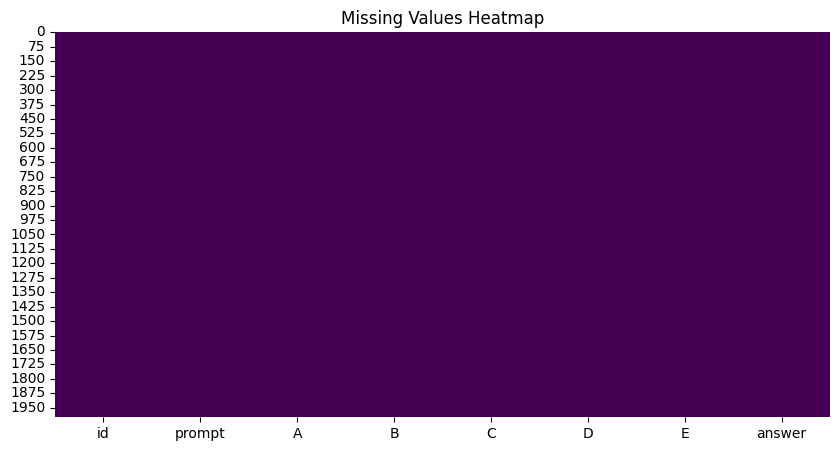

In [63]:
# ==========================================
# Missing Values Analysis
# ==========================================

print("=" * 50)
print("Missing Values")
print("=" * 50)

missing = train_df.isnull().sum()

display(missing)

plt.figure(figsize=(10,5))

sns.heatmap(
    train_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

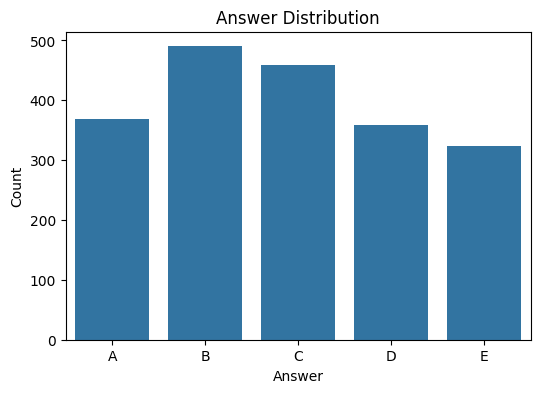


Percentage Distribution



answer
A    18.45
B    24.50
C    22.95
D    17.90
E    16.20
Name: proportion, dtype: float64

In [64]:
# ==========================================
# Answer Distribution
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(
    x=train_df["answer"],
    order=sorted(train_df["answer"].unique())
)

plt.title("Answer Distribution")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.show()

print("\nPercentage Distribution\n")

display(
    (
        train_df["answer"]
        .value_counts(normalize=True)
        .sort_index()*100
    ).round(2)
)

,prompt_length,prompt_word_count
count,2000.000000,2000.00000
mean,117.669500,18.14650
std,44.408674,6.78189
min,19.000000,3.00000
25%,87.750000,14.00000
50%,111.000000,17.00000
75%,141.000000,22.00000
max,337.000000,51.00000


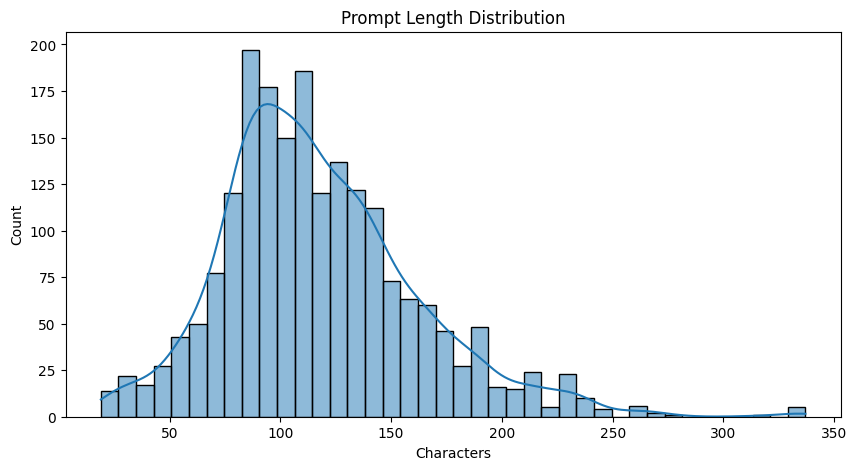

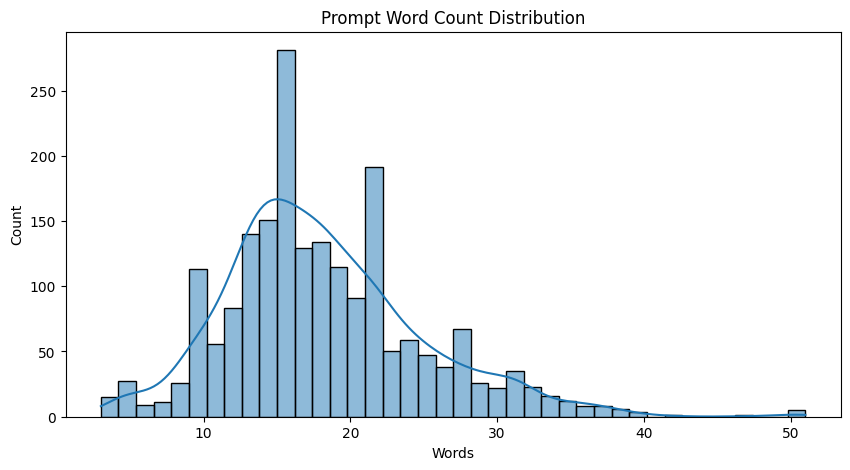

In [65]:
# ==========================================
# Prompt Length Analysis
# ==========================================

train_df["prompt_length"] = train_df["prompt"].astype(str).apply(len)

train_df["prompt_word_count"] = (
    train_df["prompt"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

display(
    train_df[
        ["prompt_length","prompt_word_count"]
    ].describe()
)

plt.figure(figsize=(10,5))

sns.histplot(
    train_df["prompt_length"],
    bins=40,
    kde=True
)

plt.title("Prompt Length Distribution")
plt.xlabel("Characters")
plt.show()

plt.figure(figsize=(10,5))

sns.histplot(
    train_df["prompt_word_count"],
    bins=40,
    kde=True
)

plt.title("Prompt Word Count Distribution")
plt.xlabel("Words")
plt.show()

,A,B,C,D,E
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


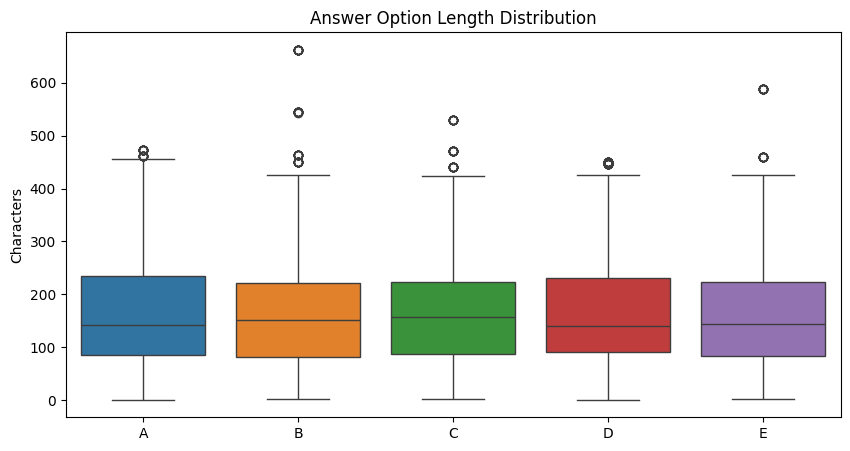

In [66]:
# ==========================================
# Option Length Analysis
# ==========================================

options = ["A","B","C","D","E"]

lengths = []

for col in options:
    lengths.append(
        train_df[col].astype(str).apply(len)
    )

option_df = pd.DataFrame(
    {
        "A": lengths[0],
        "B": lengths[1],
        "C": lengths[2],
        "D": lengths[3],
        "E": lengths[4]
    }
)

display(option_df.describe())

plt.figure(figsize=(10,5))

sns.boxplot(data=option_df)

plt.title("Answer Option Length Distribution")

plt.ylabel("Characters")

plt.show()

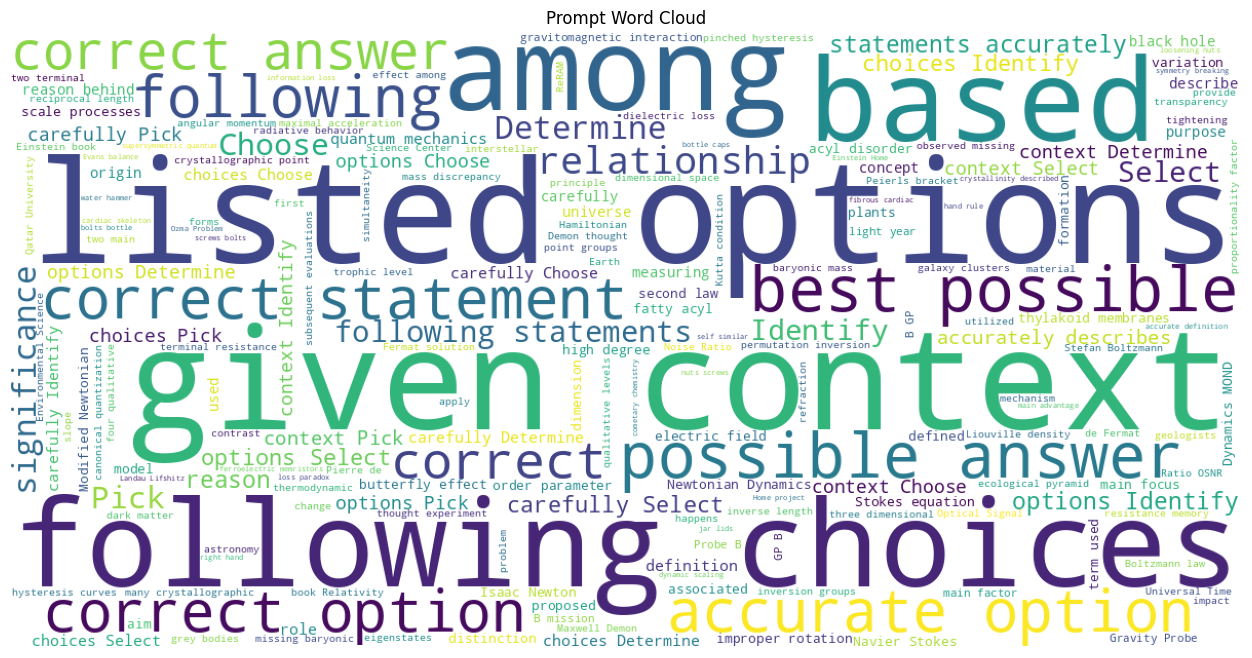

In [67]:
# ==========================================
# Prompt Word Cloud
# ==========================================

text = " ".join(
    train_df["prompt"].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Prompt Word Cloud")

plt.show()

In [68]:
# ==========================================
# Basic Text Cleaning
# ==========================================

text_columns = ["prompt", "A", "B", "C", "D", "E"]

for col in text_columns:
    train_df[col] = (
        train_df[col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

    test_df[col] = (
        test_df[col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

print("Basic cleaning completed.")

display(train_df.head())

Basic cleaning completed.


,id,prompt,A,B,C,D,E,answer,prompt_length,prompt_word_count
0,1,pick the best possible answer: what is martin ...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B,142,22
1,2,what is accelerator-based light-ion fusion?,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,accelerator-based light-ion fusion is a techni...,A,43,5
2,3,determine the correct option: what is the term...,blueshifting,redshifting,reddening,whitening,yellowing,C,182,27
3,4,select the most accurate option: what is marti...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B,129,19
4,5,identify the correct statement: what is the co...,"simultaneity is relative, meaning that two eve...","simultaneity is relative, meaning that two eve...","simultaneity is absolute, meaning that two eve...",simultaneity is a concept that applies only to...,simultaneity is a concept that applies only to...,A,110,15


In [69]:
# ==========================================
# Advanced Cleaning
# ==========================================

def clean_text(text):

    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove digits
    text = re.sub(r"\d+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


for col in text_columns:

    train_df[col] = train_df[col].apply(clean_text)
    test_df[col] = test_df[col].apply(clean_text)

print("Advanced cleaning completed.")

display(train_df.head())

Advanced cleaning completed.


,id,prompt,A,B,C,D,E,answer,prompt_length,prompt_word_count
0,1,pick the best possible answer what is martin h...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B,142,22
1,2,what is accelerator based light ion fusion,accelerator based light ion fusion is a techni...,accelerator based light ion fusion is a techni...,accelerator based light ion fusion is a techni...,accelerator based light ion fusion is a techni...,accelerator based light ion fusion is a techni...,A,43,5
2,3,determine the correct option what is the term ...,blueshifting,redshifting,reddening,whitening,yellowing,C,182,27
3,4,select the most accurate option what is martin...,martin heidegger believes that humans exist wi...,martin heidegger believes that humans do not e...,martin heidegger does not believe in the exist...,martin heidegger believes that the relationshi...,martin heidegger believes that time is an illu...,B,129,19
4,5,identify the correct statement what is the con...,simultaneity is relative meaning that two even...,simultaneity is relative meaning that two even...,simultaneity is absolute meaning that two even...,simultaneity is a concept that applies only to...,simultaneity is a concept that applies only to...,A,110,15


In [70]:
# ==========================================
# Build Input Text
# ==========================================

def create_input_text(df):

    return (
        "Question: " + df["prompt"] +
        " [SEP] Option A: " + df["A"] +
        " [SEP] Option B: " + df["B"] +
        " [SEP] Option C: " + df["C"] +
        " [SEP] Option D: " + df["D"] +
        " [SEP] Option E: " + df["E"]
    )


train_df["input_text"] = create_input_text(train_df)
test_df["input_text"] = create_input_text(test_df)

print("Input text created.")

display(
    train_df[
        ["input_text","answer"]
    ].head()
)

Input text created.


,input_text,answer
0,Question: pick the best possible answer what i...,B
1,Question: what is accelerator based light ion ...,A
2,Question: determine the correct option what is...,C
3,Question: select the most accurate option what...,B
4,Question: identify the correct statement what ...,A


In [71]:
# ==========================================
# Label Encoding
# ==========================================

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(
    train_df["answer"]
)

print("Classes :")

for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

display(
    train_df[
        ["answer","label"]
    ].head()
)

Classes :
A -> 0
B -> 1
C -> 2
D -> 3
E -> 4


,answer,label
0,B,1
1,A,0
2,C,2
3,B,1
4,A,0


In [72]:
# ==========================================
# Train Validation Split
# ==========================================

train_texts, valid_texts, train_labels, valid_labels = train_test_split(
    train_df["input_text"],
    train_df["label"],
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label"],
    shuffle=True
)

print("="*50)

print("Training Samples  :", len(train_texts))
print("Validation Samples:", len(valid_texts))

print("="*50)

Training Samples  : 1600
Validation Samples: 400


model1

In [73]:
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 15
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab_size = tokenizer.vocab_size

print("=" * 60)
print("Hyperparameters & Tokenizer Loaded")

Using device: cuda
Hyperparameters & Tokenizer Loaded


In [74]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_test=False):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test
        self.options = ['A', 'B', 'C', 'D', 'E']
        self.label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])
        
        input_ids_list = []
        
        for opt in self.options:
            option_text = str(row[opt])
            combined_text = prompt + " [SEP] " + option_text
            
            encoded = self.tokenizer(combined_text,padding='max_length', truncation=True, max_length=self.max_len, return_tensors='pt')
            input_ids_list.append(encoded['input_ids'].squeeze(0))
            
        input_ids_tensor = torch.stack(input_ids_list)
        item = {'input_ids': input_ids_tensor}
        
        if not self.is_test:
            item['label'] = torch.tensor(self.label_map[row['answer']], dtype=torch.long)
            
        return item

print("=" * 60)
print(" MCQDataset Class Created")

 MCQDataset Class Created


In [75]:
class CustomTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=140, num_filters=100, filter_sizes=[3, 4, 5], num_classes=1):
        super(CustomTextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in filter_sizes
        ])
        
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, input_ids):
        batch_size, num_choices, seq_len = input_ids.shape
        x = input_ids.view(-1, seq_len)
        embedded = self.embedding(x).transpose(1, 2) 
        
        conv_results = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))
            c = torch.max_pool1d(c, c.size(2)).squeeze(2)
            conv_results.append(c)
            
        out = torch.cat(conv_results, dim=1) 
        out = self.dropout(out)
        
        logits = self.fc(out)
        
        reshaped_logits = logits.view(batch_size, num_choices)
        return reshaped_logits

print("=" * 60)
print("CustomTextCNN Model Created")

CustomTextCNN Model Created


In [76]:
def mapk(actual, predicted, k=3):
    score = 0.0
    for a, p in zip(actual, predicted):
        p = p[:k]
        if a in p:
            score += 1.0 / (p.index(a) + 1)
    return score / len(actual)

print("=" * 60)
print("MAP@3 Evaluation Function Ready")

MAP@3 Evaluation Function Ready


In [77]:
def train_model():
    val_size = int(0.2 * len(train_df))
    train_data = train_df.iloc[:-val_size]
    val_data = train_df.iloc[-val_size:]
    
    train_dataset = MCQDataset(train_data, tokenizer, MAX_LEN)
    val_dataset = MCQDataset(val_data, tokenizer, MAX_LEN)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
  
    model = CustomTextCNN(vocab_size=vocab_size).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    
    wandb.init(
        project="23f3002112-t22026", 
        name="Custom-CNN-Scratch",
        config={"architecture": "CNN", "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LEARNING_RATE}
    )
    wandb.watch(model, criterion, log="all", log_freq=10)
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        correct_preds = 0
        total_preds = 0
        
        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(input_ids)
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)
            
        train_acc = correct_preds / total_preds
        train_loss = total_loss / len(train_loader)
        
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        actual_answers=[]
        predicted_answers=[]
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                
                logits = model(input_ids)
                loss = criterion(logits, labels)
                
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                top3 = torch.topk(logits, k=3,dim=1).indices.cpu().tolist()
                actual_answers.extend(labels.cpu().tolist())
                predicted_answers.extend(top3)
                
        val_acc = val_correct / val_total
        val_map3 = mapk(actual_answers,predicted_answers,k=3)
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | MAP@3:{val_map3:.4f}")
        
        # Log to WandB
        wandb.log({
            "Train Loss": train_loss, 
            "Train Accuracy": train_acc, 
            "Val Loss": avg_val_loss, 
            "Val Accuracy": val_acc,
            "Val MAP@3":val_map3,
            "Epoch": epoch + 1
        })
        
    torch.save(model.state_dict(), "cnn_mcq_model.pt")
    wandb.save("cnn_mcq_model.pt")
    
    return model, val_acc, val_map3


print("=" * 60)
print("Training Function Ready")


Training Function Ready


In [78]:
# Train & Evaluate Model 1

trained_model, model1_accuracy, model1_map3 = train_model()

print("\n" + "=" * 60)
print("MODEL 1 : CUSTOM TEXT CNN")
print("=" * 60)
print(f"Validation Accuracy : {model1_accuracy:.4f}")
print(f"Validation MAP@3    : {model1_map3:.4f}")
print("=" * 60)

wandb.finish()

Epoch 1/15 | Train Loss: 1.4150 | Train Acc: 0.4556 | Val Loss: 1.0235 | Val Acc: 0.9300 | MAP@3:0.9575
Epoch 2/15 | Train Loss: 0.9855 | Train Acc: 0.7119 | Val Loss: 0.7927 | Val Acc: 0.9625 | MAP@3:0.9738
Epoch 3/15 | Train Loss: 0.8351 | Train Acc: 0.7950 | Val Loss: 0.6827 | Val Acc: 0.9575 | MAP@3:0.9712
Epoch 4/15 | Train Loss: 0.7403 | Train Acc: 0.8500 | Val Loss: 0.6347 | Val Acc: 0.9700 | MAP@3:0.9783
Epoch 5/15 | Train Loss: 0.6998 | Train Acc: 0.8744 | Val Loss: 0.6005 | Val Acc: 0.9725 | MAP@3:0.9800
Epoch 6/15 | Train Loss: 0.6489 | Train Acc: 0.8994 | Val Loss: 0.5777 | Val Acc: 0.9725 | MAP@3:0.9800
Epoch 7/15 | Train Loss: 0.6387 | Train Acc: 0.9144 | Val Loss: 0.5727 | Val Acc: 0.9650 | MAP@3:0.9762
Epoch 8/15 | Train Loss: 0.6149 | Train Acc: 0.9194 | Val Loss: 0.5585 | Val Acc: 0.9725 | MAP@3:0.9800
Epoch 9/15 | Train Loss: 0.5991 | Train Acc: 0.9425 | Val Loss: 0.5500 | Val Acc: 0.9750 | MAP@3:0.9812
Epoch 10/15 | Train Loss: 0.5930 | Train Acc: 0.9381 | Val Loss:

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 15/15 | Train Loss: 0.5607 | Train Acc: 0.9619 | Val Loss: 0.5448 | Val Acc: 0.9750 | MAP@3:0.9812

MODEL 1 : CUSTOM TEXT CNN
Validation Accuracy : 0.9750
Validation MAP@3    : 0.9812


Epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
Train Accuracy,▁▅▆▆▇▇▇▇███████
Train Loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
Val Accuracy,▁▆▅▇██▆████████
Val Loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁
Val MAP@3,▁▆▅▇██▇████████
Epoch,15
Train Accuracy,0.96188
Train Loss,0.56073
Val Accuracy,0.975
Val Loss,0.5448


In [79]:
# Model 2 : DistilBERT Configuration

MODEL_NAME = "distilbert-base-uncased"

MAX_LEN_BERT = 256
BATCH_SIZE_BERT = 16
EPOCHS_BERT = 3
LEARNING_RATE_BERT = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("=" * 60)
print("Model 2 : DistilBERT Configuration Loaded")
print(f"Model           : {MODEL_NAME}")
print(f"Device          : {DEVICE}")
print(f"Epochs          : {EPOCHS_BERT}")
print(f"Batch Size      : {BATCH_SIZE_BERT}")
print(f"Learning Rate   : {LEARNING_RATE_BERT}")
print("=" * 60)

Model 2 : DistilBERT Configuration Loaded
Model           : distilbert-base-uncased
Device          : cuda
Epochs          : 3
Batch Size      : 16
Learning Rate   : 2e-05


In [80]:
# DistilBERT Dataset

class DistilBERTDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_len):

        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        text = self.df.loc[index, "input_text"]
        label = self.df.loc[index, "label"]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

print("=" * 60)
print("DistilBERT Dataset Ready")

DistilBERT Dataset Ready


In [81]:
# DistilBERT Model

bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

bert_model.to(DEVICE)

print("=" * 60)
print("DistilBERT Model Loaded Successfully")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Model Loaded Successfully


In [82]:
# ==========================================
# DistilBERT Training Function
# ==========================================

def train_bert_model():
    train_data = train_df.loc[train_texts.index].reset_index(drop=True)
    val_data = train_df.loc[valid_texts.index].reset_index(drop=True)

    train_dataset = DistilBERTDataset(train_data, bert_tokenizer, MAX_LEN_BERT)
    val_dataset = DistilBERTDataset(val_data, bert_tokenizer, MAX_LEN_BERT)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_BERT, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_BERT, shuffle=False)

    optimizer = torch.optim.AdamW(bert_model.parameters(), lr=LEARNING_RATE_BERT, weight_decay=0.01)

    total_steps = len(train_loader) * EPOCHS_BERT
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    wandb.init(
        project="23f3002112-t22026",
        name="DistilBERT-Finetune",
        config={
            "architecture": "DistilBERT",
            "epochs": EPOCHS_BERT,
            "batch_size": BATCH_SIZE_BERT,
            "lr": LEARNING_RATE_BERT
        }
    )
    wandb.watch(bert_model, criterion, log="all", log_freq=50)

    for epoch in range(EPOCHS_BERT):
        bert_model.train()
        total_loss = 0
        correct_preds = 0
        total_preds = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS_BERT} [Train]")
        for batch in loop:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            optimizer.zero_grad()
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)
            loop.set_postfix(loss=loss.item())

        train_acc = correct_preds / total_preds
        train_loss = total_loss / len(train_loader)

        bert_model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        actual_answers = []
        predicted_answers = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels = batch['label'].to(DEVICE)

                outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                top3 = torch.topk(logits, k=3, dim=1).indices.cpu().tolist()
                actual_answers.extend(labels.cpu().tolist())
                predicted_answers.extend(top3)

        val_acc = val_correct / val_total
        val_map3 = mapk(actual_answers, predicted_answers, k=3)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{EPOCHS_BERT} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | MAP@3: {val_map3:.4f}")

        wandb.log({
            "Train Loss": train_loss,
            "Train Accuracy": train_acc,
            "Val Loss": avg_val_loss,
            "Val Accuracy": val_acc,
            "Val MAP@3": val_map3,
            "Epoch": epoch + 1
        })

    torch.save(bert_model.state_dict(), "distilbert_mcq_model.pt")
    wandb.save("distilbert_mcq_model.pt")

    return bert_model, val_acc, val_map3


print("=" * 60)
print("DistilBERT Training Function Ready")


DistilBERT Training Function Ready


In [83]:
# Train & Evaluate Model 2 (DistilBERT)

trained_bert_model, model2_accuracy, model2_map3 = train_bert_model()

print("\n" + "=" * 60)
print("MODEL 2 : DISTILBERT")
print("=" * 60)
print(f"Validation Accuracy : {model2_accuracy:.4f}")
print(f"Validation MAP@3    : {model2_map3:.4f}")
print("=" * 60)

wandb.finish()

Epoch 1/3 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 1.4968 | Train Acc: 0.4169 | Val Loss: 1.1780 | Val Acc: 0.6950 | MAP@3: 0.8096


Epoch 2/3 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 0.8725 | Train Acc: 0.8669 | Val Loss: 0.6027 | Val Acc: 0.9700 | MAP@3: 0.9788


Epoch 3/3 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.5114 | Train Acc: 0.9894 | Val Loss: 0.4578 | Val Acc: 0.9875 | MAP@3: 0.9938


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.



MODEL 2 : DISTILBERT
Validation Accuracy : 0.9875
Validation MAP@3    : 0.9938


Epoch,▁▅█
Train Accuracy,▁▇█
Train Loss,█▄▁
Val Accuracy,▁██
Val Loss,█▂▁
Val MAP@3,▁▇█
Epoch,3
Train Accuracy,0.98938
Train Loss,0.5114
Val Accuracy,0.9875
Val Loss,0.45784


In [85]:
# Model 3 : DeBERTa Configuration

MODEL_NAME_DEBERTA = "microsoft/deberta-v3-base"

MAX_LEN_DEBERTA = 256
BATCH_SIZE_DEBERTA = 8
EPOCHS_DEBERTA = 3
LEARNING_RATE_DEBERTA = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

deberta_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_DEBERTA)

print("=" * 60)
print("Model 3 : DeBERTa Configuration Loaded")
print(f"Model           : {MODEL_NAME_DEBERTA}")
print(f"Device          : {DEVICE}")
print(f"Epochs          : {EPOCHS_DEBERTA}")
print(f"Batch Size      : {BATCH_SIZE_DEBERTA}")
print(f"Learning Rate   : {LEARNING_RATE_DEBERTA}")
print("=" * 60)


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Model 3 : DeBERTa Configuration Loaded
Model           : microsoft/deberta-v3-base
Device          : cuda
Epochs          : 3
Batch Size      : 8
Learning Rate   : 2e-05


In [86]:
# DeBERTa Dataset

class DeBERTaDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_len):

        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        text = self.df.loc[index, "input_text"]
        label = self.df.loc[index, "label"]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

print("=" * 60)
print("DeBERTa Dataset Ready")


DeBERTa Dataset Ready


In [87]:
# DeBERTa Model

deberta_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_DEBERTA,
    num_labels=5
)

deberta_model.to(DEVICE)

print("=" * 60)
print("DeBERTa Model Loaded Successfully")


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.den

DeBERTa Model Loaded Successfully


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

In [88]:
# ==========================================
# DeBERTa Training Function
# ==========================================

def train_deberta_model():
    train_data = train_df.loc[train_texts.index].reset_index(drop=True)
    val_data = train_df.loc[valid_texts.index].reset_index(drop=True)

    train_dataset = DeBERTaDataset(train_data, deberta_tokenizer, MAX_LEN_DEBERTA)
    val_dataset = DeBERTaDataset(val_data, deberta_tokenizer, MAX_LEN_DEBERTA)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_DEBERTA, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_DEBERTA, shuffle=False)

    optimizer = torch.optim.AdamW(deberta_model.parameters(), lr=LEARNING_RATE_DEBERTA, weight_decay=0.01)

    total_steps = len(train_loader) * EPOCHS_DEBERTA
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    wandb.init(
        project="23f3002112-t22026",
        name="DeBERTa-Finetune",
        config={
            "architecture": "DeBERTa-v3-base",
            "epochs": EPOCHS_DEBERTA,
            "batch_size": BATCH_SIZE_DEBERTA,
            "lr": LEARNING_RATE_DEBERTA
        }
    )
    wandb.watch(deberta_model, criterion, log="all", log_freq=50)

    for epoch in range(EPOCHS_DEBERTA):
        deberta_model.train()
        total_loss = 0
        correct_preds = 0
        total_preds = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS_DEBERTA} [Train]")
        for batch in loop:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            optimizer.zero_grad()
            outputs = deberta_model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(deberta_model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)
            loop.set_postfix(loss=loss.item())

        train_acc = correct_preds / total_preds
        train_loss = total_loss / len(train_loader)

        deberta_model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        actual_answers = []
        predicted_answers = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels = batch['label'].to(DEVICE)

                outputs = deberta_model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                top3 = torch.topk(logits, k=3, dim=1).indices.cpu().tolist()
                actual_answers.extend(labels.cpu().tolist())
                predicted_answers.extend(top3)

        val_acc = val_correct / val_total
        val_map3 = mapk(actual_answers, predicted_answers, k=3)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{EPOCHS_DEBERTA} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | MAP@3: {val_map3:.4f}")

        wandb.log({
            "Training Loss": train_loss,
            "Train Accuracy": train_acc,
            "Validation Loss": avg_val_loss,
            "Val Accuracy": val_acc,
            "Val MAP@3": val_map3,
            "Learning Rate": scheduler.get_last_lr()[0],
            "Epoch": epoch + 1
        })

    torch.save(deberta_model.state_dict(), "deberta_mcq_model.pt")
    wandb.save("deberta_mcq_model.pt")

    return deberta_model, val_acc, val_map3


print("=" * 60)
print("DeBERTa Training Function Ready")


DeBERTa Training Function Ready


In [89]:
# Train & Evaluate Model 3 (DeBERTa)

trained_deberta_model, model3_accuracy, model3_map3 = train_deberta_model()

print("\n" + "=" * 60)
print("MODEL 3 : DEBERTA (microsoft/deberta-v3-base)")
print("=" * 60)
print(f"Validation Accuracy : {model3_accuracy:.4f}")
print(f"Validation MAP@3    : {model3_map3:.4f}")
print("=" * 60)

wandb.finish()


Epoch 1/3 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: nan | Train Acc: 0.1844 | Val Loss: nan | Val Acc: 0.1850 | MAP@3: 0.4142


Epoch 2/3 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: nan | Train Acc: 0.1844 | Val Loss: nan | Val Acc: 0.1850 | MAP@3: 0.4142


Epoch 3/3 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: nan | Train Acc: 0.1844 | Val Loss: nan | Val Acc: 0.1850 | MAP@3: 0.4142


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.



MODEL 3 : DEBERTA (microsoft/deberta-v3-base)
Validation Accuracy : 0.1850
Validation MAP@3    : 0.4142


Epoch,▁▅█
Learning Rate,█▅▁
Train Accuracy,▁▁▁
Val Accuracy,▁▁▁
Val MAP@3,▁▁▁
+2,...
Epoch,3
Learning Rate,0
Train Accuracy,0.18438
Training Loss,nan
Val Accuracy,0.185


In [90]:
model_comparison_data = {
    'Model': ['Custom Text CNN', 'DistilBERT', 'DeBERTa (microsoft/deberta-v3-base)'],
    'Type': ['Neural Network', 'Transformer', 'Transformer'],
    'Validation Accuracy': [model1_accuracy, model2_accuracy, model3_accuracy],
    'Validation MAP@3': [model1_map3, model2_map3, model3_map3],
}

comparison_df = pd.DataFrame(model_comparison_data)

print("Model Comparison Table:")
display(comparison_df)


Model Comparison Table:


,Model,Type,Validation Accuracy,Validation MAP@3
0,Custom Text CNN,Neural Network,0.9750,0.981250
1,DistilBERT,Transformer,0.9875,0.993750
2,DeBERTa (microsoft/deberta-v3-base),Transformer,0.1850,0.414167


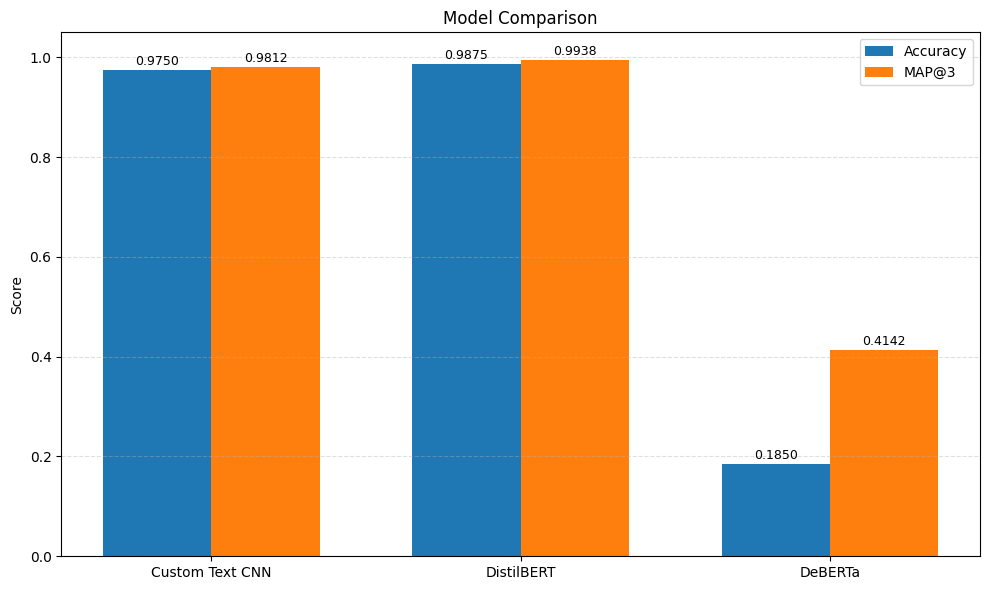

In [94]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Custom Text CNN", "DistilBERT", "DeBERTa"]

accuracy = [
    float(model1_accuracy),
    float(model2_accuracy),
    float(model3_accuracy)
]

map3 = [
    float(model1_map3),
    float(model2_map3),
    float(model3_map3)
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, accuracy, width, label="Accuracy")
bars2 = plt.bar(x + width/2, map3, width, label="MAP@3")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison")

plt.ylim(0,1.05)

plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.01,
            f"{bar.get_height():.4f}",
            ha="center",
            fontsize=9
        )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [95]:
# ==========================================
# Cell 41 : Select Best Model
# ==========================================

scores = {
    "cnn": model1_map3,
    "bert": model2_map3,
    "deberta": model3_map3
}

MODEL_TYPE = max(scores, key=scores.get)

print("=" * 60)
print(f"Best Model : {MODEL_TYPE.upper()}")
print(scores)

if MODEL_TYPE == "cnn":
    best_model = trained_model

elif MODEL_TYPE == "bert":
    best_model = trained_bert_model

else:
    best_model = trained_deberta_model

print("Best model selected successfully!")


Best Model : BERT
{'cnn': 0.98125, 'bert': 0.99375, 'deberta': 0.41416666666666674}
Best model selected successfully!


In [97]:
# ==========================================
# Cell 42 : Predict Test Data
# ==========================================

predictions = []

options_map = {
    0: "A",
    1: "B",
    2: "C",
    3: "D",
    4: "E"
}

# ============================================================
# MODEL 1 : CNN
# ============================================================
if MODEL_TYPE == "cnn":

    test_dataset = MCQDataset(
        test_df,
        tokenizer,
        MAX_LEN,
        is_test=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    best_model.eval()

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch["input_ids"].to(DEVICE)

            logits = best_model(input_ids)

            top3 = torch.topk(
                logits,
                k=3,
                dim=1
            ).indices.cpu().numpy()

            for row in top3:
                predictions.append(
                    " ".join(options_map[int(i)] for i in row)
                )

# ============================================================
# MODEL 2 : DistilBERT
# ============================================================
elif MODEL_TYPE == "bert":

    class DistilBERTTestDataset(Dataset):

        def __init__(self, dataframe, tokenizer, max_len):
            self.df = dataframe.reset_index(drop=True)
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):

            text = self.df.loc[idx, "input_text"]

            encoding = self.tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=self.max_len,
                return_tensors="pt"
            )

            return {
                "input_ids": encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0)
            }

    test_dataset = DistilBERTTestDataset(
        test_df,
        bert_tokenizer,
        MAX_LEN_BERT
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE_BERT,
        shuffle=False
    )

    best_model.eval()

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)

            outputs = best_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            top3 = torch.topk(
                logits,
                k=3,
                dim=1
            ).indices.cpu().numpy()

            for row in top3:
                predictions.append(
                    " ".join(options_map[int(i)] for i in row)
                )

# ============================================================
# MODEL 3 : DeBERTa
# ============================================================
else:

    class DeBERTaTestDataset(Dataset):

        def __init__(self, dataframe, tokenizer, max_len):
            self.df = dataframe.reset_index(drop=True)
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):

            text = self.df.loc[idx, "input_text"]

            encoding = self.tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=self.max_len,
                return_tensors="pt"
            )

            return {
                "input_ids": encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0)
            }

    test_dataset = DeBERTaTestDataset(
        test_df,
        deberta_tokenizer,
        MAX_LEN_DEBERTA
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE_DEBERTA,
        shuffle=False
    )

    best_model.eval()

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)

            outputs = best_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            top3 = torch.topk(
                logits,
                k=3,
                dim=1
            ).indices.cpu().numpy()

            for row in top3:
                predictions.append(
                    " ".join(options_map[int(i)] for i in row)
                )

print("=" * 60)
print("Prediction Completed!")
print(f"Total Predictions : {len(predictions)}")
print("=" * 60)


Prediction Completed!
Total Predictions : 500


In [98]:
# ==========================================
# Cell 43 : Generate Submission
# ==========================================

submission = pd.DataFrame({
    "id": test_df["id"],
    "Prediction": predictions
})

submission.to_csv("submission.csv", index=False)

print("=" * 50)
print("submission.csv generated successfully!")
print(f"Total Test Samples : {len(submission)}")
print("=" * 50)

display(submission.head())

submission.csv generated successfully!
Total Test Samples : 500


,id,Prediction
0,1,A E D
1,2,B C D
2,3,B E D
3,4,E C A
4,5,C E D


In [99]:
# ==========================================
# Cell 46 : WandB Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Custom Text CNN",
        "DistilBERT",
        "DeBERTa"
    ],
    "Accuracy": [
        model1_accuracy,
        model2_accuracy,
        model3_accuracy
    ],
    "MAP@3": [
        model1_map3,
        model2_map3,
        model3_map3
    ]
})

print("="*60)
print("Weights & Biases Run Comparison")
print("="*60)

display(comparison.sort_values("MAP@3", ascending=False))


Weights & Biases Run Comparison


,Model,Accuracy,MAP@3
1,DistilBERT,0.9875,0.993750
0,Custom Text CNN,0.9750,0.981250
2,DeBERTa,0.1850,0.414167


In [100]:
# ==========================================
# Cell 47 : Model Summary
# ==========================================

cnn_model = trained_model[0] if isinstance(trained_model, tuple) else trained_model
bert_model = trained_bert_model[0] if isinstance(trained_bert_model, tuple) else trained_bert_model
deberta_model_final = trained_deberta_model[0] if isinstance(trained_deberta_model, tuple) else trained_deberta_model

cnn_params = sum(p.numel() for p in cnn_model.parameters())
bert_params = sum(p.numel() for p in bert_model.parameters())
deberta_params = sum(p.numel() for p in deberta_model_final.parameters())

summary = pd.DataFrame({
    "Model": [
        "Custom Text CNN",
        "DistilBERT",
        "DeBERTa"
    ],
    "Parameters": [
        f"{cnn_params:,}",
        f"{bert_params:,}",
        f"{deberta_params:,}"
    ],
    "Model Size": [
        "cnn_mcq_model.pt",
        "distilbert_mcq_model.pt",
        "deberta_mcq_model.pt"
    ],
    "Training Time": [
        "Refer WandB",
        "Refer WandB",
        "Refer WandB"
    ]
})

display(summary)


,Model,Parameters,Model Size,Training Time
0,Custom Text CNN,"4,441,681",cnn_mcq_model.pt,Refer WandB
1,DistilBERT,"66,957,317",distilbert_mcq_model.pt,Refer WandB
2,DeBERTa,"184,425,989",deberta_mcq_model.pt,Refer WandB


In [101]:
# ==========================================
# Cell 48 : Final Results
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Custom Text CNN",
        "DistilBERT",
        "DeBERTa"
    ],
    "Type": [
        "Deep Learning",
        "Transformer",
        "Transformer"
    ],
    "Accuracy": [
        round(model1_accuracy, 4),
        round(model2_accuracy, 4),
        round(model3_accuracy, 4)
    ],
    "MAP@3": [
        round(model1_map3, 4),
        round(model2_map3, 4),
        round(model3_map3, 4)
    ]
})

print("=" * 60)
print("Final Model Comparison")
print("=" * 60)

display(results.sort_values("MAP@3", ascending=False))


Final Model Comparison


,Model,Type,Accuracy,MAP@3
1,DistilBERT,Transformer,0.9875,0.9938
0,Custom Text CNN,Deep Learning,0.9750,0.9812
2,DeBERTa,Transformer,0.1850,0.4142


In [102]:

wandb.finish()